In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("sales_data.csv")

# A raw copy is created with typical data-quality problems so that the
# cleaning operations can be demonstrated.
raw = df.copy()
raw.loc[3, "Sales"] = np.nan            # missing value
raw.loc[11, "Sales"] = np.nan           # missing value
raw.loc[7, "Region"] = np.nan           # missing category
raw.loc[2, "Product"] = " printer "     # extra spaces + lower case
raw.loc[9, "Product"] = "LAPTOP"        # inconsistent case
raw = pd.concat([raw, raw.iloc[[0, 1]]], ignore_index=True)   # duplicate rows

print("Raw dataset shape :", raw.shape)
raw.head(12)

Raw dataset shape : (32, 3)


,Product,Region,Sales
0,Laptop,North,50000.0
1,Mobile,South,35000.0
2,printer,East,25000.0
3,Laptop,West,NaN
4,Mobile,North,40000.0
5,Printer,South,30000.0
6,Laptop,East,55000.0
7,Mobile,NaN,38000.0
8,Printer,North,28000.0
9,LAPTOP,South,48000.0


In [2]:
# ---------------- Inspecting the data quality ----------------
print("Missing values in each column:")
print(raw.isnull().sum())

print("\nTotal missing values :", raw.isnull().sum().sum())
print("Duplicate rows       :", raw.duplicated().sum())

print("\nData types:")
print(raw.dtypes)

print("\nUnique values in the Product column:")
print(raw["Product"].unique())

Missing values in each column:
Product    0
Region     1
Sales      2
dtype: int64

Total missing values : 3
Duplicate rows       : 2

Data types:
Product        str
Region         str
Sales      float64
dtype: object

Unique values in the Product column:
<StringArray>
['Laptop', 'Mobile', ' printer ', 'Printer', 'LAPTOP']
Length: 5, dtype: str


In [3]:
# ---------------- Handling missing values ----------------
clean = raw.copy()

# (a) numeric column -> replace with the mean
mean_sales = clean["Sales"].mean()
clean["Sales"] = clean["Sales"].fillna(round(mean_sales, 2))
print("(a) Missing Sales values replaced with the mean :", round(mean_sales, 2))

# (b) categorical column -> replace with the mode
mode_region = clean["Region"].mode()[0]
clean["Region"] = clean["Region"].fillna(mode_region)
print("(b) Missing Region values replaced with the mode :", mode_region)

print("\nMissing values after cleaning:")
print(clean.isnull().sum())

# (c) dropna() removes the rows that still contain missing values
print("\nRows before dropna() :", len(clean))
print("Rows after  dropna() :", len(clean.dropna()))

(a) Missing Sales values replaced with the mean : 40466.67
(b) Missing Region values replaced with the mode : North

Missing values after cleaning:
Product    0
Region     0
Sales      0
dtype: int64

Rows before dropna() : 32
Rows after  dropna() : 32


In [4]:
# ---------------- Removing duplicate records ----------------
print("Rows before removing duplicates :", len(clean))
print("Duplicate rows found            :", clean.duplicated().sum())

print("\nThe duplicate rows are:")
print(clean[clean.duplicated()])

clean = clean.drop_duplicates().reset_index(drop=True)
print("\nRows after removing duplicates  :", len(clean))

Rows before removing duplicates : 32
Duplicate rows found            : 2

The duplicate rows are:
   Product Region    Sales
30  Laptop  North  50000.0
31  Mobile  South  35000.0

Rows after removing duplicates  : 30


In [5]:
# ---------------- Cleaning inconsistent text entries ----------------
print("Product values before cleaning :", clean["Product"].unique())

clean["Product"] = clean["Product"].str.strip().str.title()
clean["Region"] = clean["Region"].str.strip().str.title()

print("Product values after cleaning  :", clean["Product"].unique())
print("Region values after cleaning   :", clean["Region"].unique())

print("\nValue counts after cleaning:")
print(clean["Product"].value_counts())

Product values before cleaning : <StringArray>
['Laptop', 'Mobile', ' printer ', 'Printer', 'LAPTOP']
Length: 5, dtype: str
Product values after cleaning  : <StringArray>
['Laptop', 'Mobile', 'Printer']
Length: 3, dtype: str
Region values after cleaning   : <StringArray>
['North', 'South', 'East', 'West']
Length: 4, dtype: str

Value counts after cleaning:
Product
Laptop     10
Mobile     10
Printer    10
Name: count, dtype: int64


In [6]:
# ---------------- Renaming columns and correcting data types ----------------
clean = clean.rename(columns={"Sales": "Sales_Amount"})
print("Renamed columns :", list(clean.columns))

print("\nData types before conversion:")
print(clean.dtypes)

clean["Sales_Amount"] = clean["Sales_Amount"].astype("int64")
clean["Product"] = clean["Product"].astype("category")
clean["Region"] = clean["Region"].astype("category")

print("\nData types after conversion:")
print(clean.dtypes)

Renamed columns : ['Product', 'Region', 'Sales_Amount']

Data types before conversion:
Product             str
Region              str
Sales_Amount    float64
dtype: object

Data types after conversion:
Product         category
Region          category
Sales_Amount       int64
dtype: object


Q1              : 33250.0
Q3              : 47750.0
IQR             : 14500.0
Lower boundary  : 11500.0
Upper boundary  : 69500.0

Number of outliers detected : 0
Empty DataFrame
Columns: [Product, Region, Sales_Amount]
Index: []


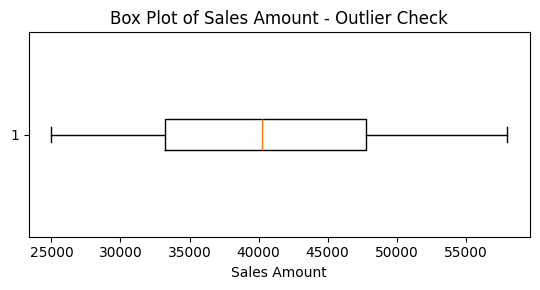

In [7]:
# ---------------- Outlier detection using the IQR method ----------------
Q1 = clean["Sales_Amount"].quantile(0.25)
Q3 = clean["Sales_Amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1              :", Q1)
print("Q3              :", Q3)
print("IQR             :", IQR)
print("Lower boundary  :", lower)
print("Upper boundary  :", upper)

outliers = clean[(clean["Sales_Amount"] < lower) | (clean["Sales_Amount"] > upper)]
print("\nNumber of outliers detected :", len(outliers))
print(outliers)

plt.figure(figsize=(5.5, 3))
plt.boxplot(clean["Sales_Amount"], vert=False)
plt.title("Box Plot of Sales Amount - Outlier Check")
plt.xlabel("Sales Amount")
plt.tight_layout()
plt.show()

In [8]:
# ---------------- Data transformation : scaling ----------------
s = clean["Sales_Amount"]

# (a) Min-Max normalisation -> values scaled to the range 0 to 1
clean["Sales_MinMax"] = ((s - s.min()) / (s.max() - s.min())).round(4)

# (b) Z-score standardisation -> mean 0, standard deviation 1
clean["Sales_ZScore"] = ((s - s.mean()) / s.std()).round(4)

# (c) Log transformation -> reduces the effect of large values
clean["Sales_Log"] = np.log(s).round(4)

print("Original  -> min:", s.min(), " max:", s.max())
print("Min-Max   -> min:", clean["Sales_MinMax"].min(),
      " max:", clean["Sales_MinMax"].max())
print("Z-Score   -> mean:", round(clean["Sales_ZScore"].mean(), 4),
      " std:", round(clean["Sales_ZScore"].std(), 4))

clean[["Product", "Sales_Amount", "Sales_MinMax", "Sales_ZScore", "Sales_Log"]].head()

Original  -> min: 25000  max: 58000
Min-Max   -> min: 0.0  max: 1.0
Z-Score   -> mean: 0.0  std: 1.0


,Product,Sales_Amount,Sales_MinMax,Sales_ZScore,Sales_Log
0,Laptop,50000,0.7576,1.0494,10.8198
1,Mobile,35000,0.3030,-0.5786,10.4631
2,Printer,25000,0.0000,-1.6639,10.1266
3,Laptop,40466,0.4687,0.0146,10.6082
4,Mobile,40000,0.4545,-0.0359,10.5966


In [9]:
# ---------------- Binning the continuous column into categories ----------------
clean["Sales_Category"] = pd.cut(
    clean["Sales_Amount"],
    bins=[0, 32000, 45000, 100000],
    labels=["Low", "Medium", "High"],
)

print("Number of records in each Sales category:")
print(clean["Sales_Category"].value_counts().sort_index())

print("\nDataset after binning:")
clean[["Product", "Region", "Sales_Amount", "Sales_Category"]].head(8)

Number of records in each Sales category:
Sales_Category
Low        7
Medium    14
High       9
Name: count, dtype: int64

Dataset after binning:


,Product,Region,Sales_Amount,Sales_Category
0,Laptop,North,50000,High
1,Mobile,South,35000,Medium
2,Printer,East,25000,Low
3,Laptop,West,40466,Medium
4,Mobile,North,40000,Medium
5,Printer,South,30000,Low
6,Laptop,East,55000,High
7,Mobile,North,38000,Medium


In [10]:
# ---------------- Encoding the categorical columns ----------------

# (a) Label encoding -> each category is replaced by a number
clean["Product_Label"] = clean["Product"].cat.codes
clean["Region_Label"] = clean["Region"].cat.codes

print("(a) Label encoding:")
print(clean[["Product", "Product_Label", "Region", "Region_Label"]].head())

# (b) One-hot encoding -> a separate 0/1 column for each category
onehot = pd.get_dummies(clean[["Product", "Region"]], dtype=int)
print("\n(b) One-hot encoded columns :", list(onehot.columns))
onehot.head()

(a) Label encoding:
   Product  Product_Label Region  Region_Label
0   Laptop              0  North             1
1   Mobile              1  South             2
2  Printer              2   East             0
3   Laptop              0   West             3
4   Mobile              1  North             1

(b) One-hot encoded columns : ['Product_Laptop', 'Product_Mobile', 'Product_Printer', 'Region_East', 'Region_North', 'Region_South', 'Region_West']


,Product_Laptop,Product_Mobile,Product_Printer,Region_East,Region_North,Region_South,Region_West
0,1,0,0,0,1,0,0
1,0,1,0,0,0,1,0
2,0,0,1,1,0,0,0
3,1,0,0,0,0,0,1
4,0,1,0,0,1,0,0


In [11]:
# ---------------- Creating a derived column using apply() ----------------
def performance(value):
    if value >= 48000:
        return "Excellent"
    elif value >= 35000:
        return "Good"
    else:
        return "Average"

clean["Performance"] = clean["Sales_Amount"].apply(performance)

# another derived column created with a lambda function
clean["Sales_in_Thousands"] = clean["Sales_Amount"].apply(lambda x: round(x / 1000, 1))

print("Performance distribution:")
print(clean["Performance"].value_counts())

clean[["Product", "Region", "Sales_Amount", "Sales_in_Thousands", "Performance"]].head(8)

Performance distribution:
Performance
Good         13
Average       9
Excellent     8
Name: count, dtype: int64


,Product,Region,Sales_Amount,Sales_in_Thousands,Performance
0,Laptop,North,50000,50.0,Excellent
1,Mobile,South,35000,35.0,Good
2,Printer,East,25000,25.0,Average
3,Laptop,West,40466,40.5,Good
4,Mobile,North,40000,40.0,Good
5,Printer,South,30000,30.0,Average
6,Laptop,East,55000,55.0,Excellent
7,Mobile,North,38000,38.0,Good


In [12]:
# ---------------- Final cleaned and transformed dataset ----------------
final = clean[["Product", "Region", "Sales_Amount", "Sales_in_Thousands",
               "Sales_MinMax", "Sales_ZScore", "Sales_Category",
               "Product_Label", "Region_Label", "Performance"]]

print("Shape of the final dataset :", final.shape)
print("Missing values remaining   :", final.isnull().sum().sum())
print("Duplicate rows remaining   :", final.duplicated().sum())

final.to_csv("cleaned_sales_data.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_sales_data.csv'")

final.head(10)

Shape of the final dataset : (30, 10)
Missing values remaining   : 0


Duplicate rows remaining   : 0

Cleaned dataset saved as 'cleaned_sales_data.csv'


,Product,Region,Sales_Amount,Sales_in_Thousands,Sales_MinMax,Sales_ZScore,Sales_Category,Product_Label,Region_Label,Performance
0,Laptop,North,50000,50.0,0.7576,1.0494,High,0,1,Excellent
1,Mobile,South,35000,35.0,0.3030,-0.5786,Medium,1,2,Good
2,Printer,East,25000,25.0,0.0000,-1.6639,Low,2,0,Average
3,Laptop,West,40466,40.5,0.4687,0.0146,Medium,0,3,Good
4,Mobile,North,40000,40.0,0.4545,-0.0359,Medium,1,1,Good
5,Printer,South,30000,30.0,0.1515,-1.1212,Low,2,2,Average
6,Laptop,East,55000,55.0,0.9091,1.5920,High,0,0,Excellent
7,Mobile,North,38000,38.0,0.3939,-0.2530,Medium,1,1,Good
8,Printer,North,28000,28.0,0.0909,-1.3383,Low,2,1,Average
9,Laptop,South,48000,48.0,0.6970,0.8323,High,0,2,Excellent
